# 國立陽明交通大學 - 多模態影像資料處理 (MMIP) 2026 Fall
## Assignment 02: 機器學習、深度學習與模型表現評估實作

- **課程名稱**：Multi-Modality Image Processing (MMIP) - Week 02
- **授課教師**：鄭中嘉 老師 (Eric Cheng, EriXNet) / 許志仲 老師 (ACVLab)
- **學生姓名**：林孟霆
- **學生學號**：`315833033`
- **作業規範**：本作業各題題目與規範嚴格擷取自本週課程簡報（第 71~75 頁），分為 Quiz 1 (30%)、Quiz 2 (40%) 與 Quiz 3 (30%)，總分 100%。
- **開發環境**：Miniconda3 (Python 3.10+) 輕量化虛擬環境，套件相容於 Anaconda / Jupyter Notebook。依賴清單已整理於 `requirements.txt`。


In [2]:
# 環境設置、套件版本驗證與資料集自動化準備
import os
import sys
import time
import torch
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch Version:    {torch.__version__} (Device: {'CUDA' if torch.cuda.is_available() else 'CPU'})")
print(f"Scikit-Learn Ver:   {sklearn.__version__}")
print(f"Pandas Version:     {pd.__version__}")
print(f"NumPy Version:      {np.__version__}")

# 確保資料集已下載至 Data/ 目錄
from Data.download_dataset import download_credit_card_dataset, prepare_quiz1_dataset
q2_csv = download_credit_card_dataset()
q1_csv = prepare_quiz1_dataset()
print("所有作業資料集已就緒於 Data/ 目錄！")


PyTorch Version:    2.14.0+cpu (Device: CPU)Scikit-Learn Ver:   1.9.1Pandas Version:     3.0.3NumPy Version:      2.4.6[Credit Card Dataset] Found existing: C:\Users\yp455\Downloads\MMIP\HW02\Data\default_of_credit_card_clients.csv  Shape: (30000, 24), Default rate: 22.12%[Quiz 1 Dataset] Found existing: C:\Users\yp455\Downloads\MMIP\HW02\Data\quiz1_breast_cancer.csv所有作業資料集已就緒於 Data/ 目錄！

---
## Quiz 1：機器學習分類任務 (Machine Learning Classification Task)

### 【基礎題 (18%)】
- **簡報題目要求（第 72 頁）**：
  1. 自行選擇一份二元分類資料集，可使用 AI 產生模擬資料（X 欄位至少 5 個），或從 Kaggle 尋找公開資料集。
  2. 使用 Scikit-Learn 基於任一 Machine Learning Classification Algorithm 建立分類模型。
  3. 將資料切分為 Training Dataset 與 Validation Dataset。
  4. 請進行適當的 Feature Scaling -> 讓數值在各欄位不要有太大的變化。
  5. 取得模型輸出的分類分數或機率，並自行決定 Classification Threshold。
  6. 基於選定 Threshold 建立 Confusion Matrix，並計算：Accuracy、Precision、Recall、F1-Score。
  7. 微調 Threshold 重新建立 Confusion Matrix，再次計算：Accuracy、Precision、Recall、F1-Score。
- **本實作選擇**：採用臨床真實乳腺腫瘤資料集（Breast Cancer Diagnostic），包含 30 個連續特徵維度。模型 1 選用邏輯斯迴歸（Logistic Regression），透過 StandardScaler 進行特徵標準化，80/20 分層抽樣切分，並比較門檻值 0.50 與 0.35 之混淆矩陣。


================================================================================Quiz 1 基礎題數值成果摘要：  - 基準門檻 (0.50): Accuracy=0.9649, Precision=0.9750, Recall=0.9286, F1=0.9512 (FN=3)  - 微調門檻 (0.35): Accuracy=0.9737, Precision=0.9756, Recall=0.9524, F1=0.9639 (FN=2)  - 門檻調校效應：將門檻調低至 0.35 後，假陰性 (FN 漏診) 由 3 例降低至 2 例，Recall 由 92.86% 提升至 95.24%！================================================================================

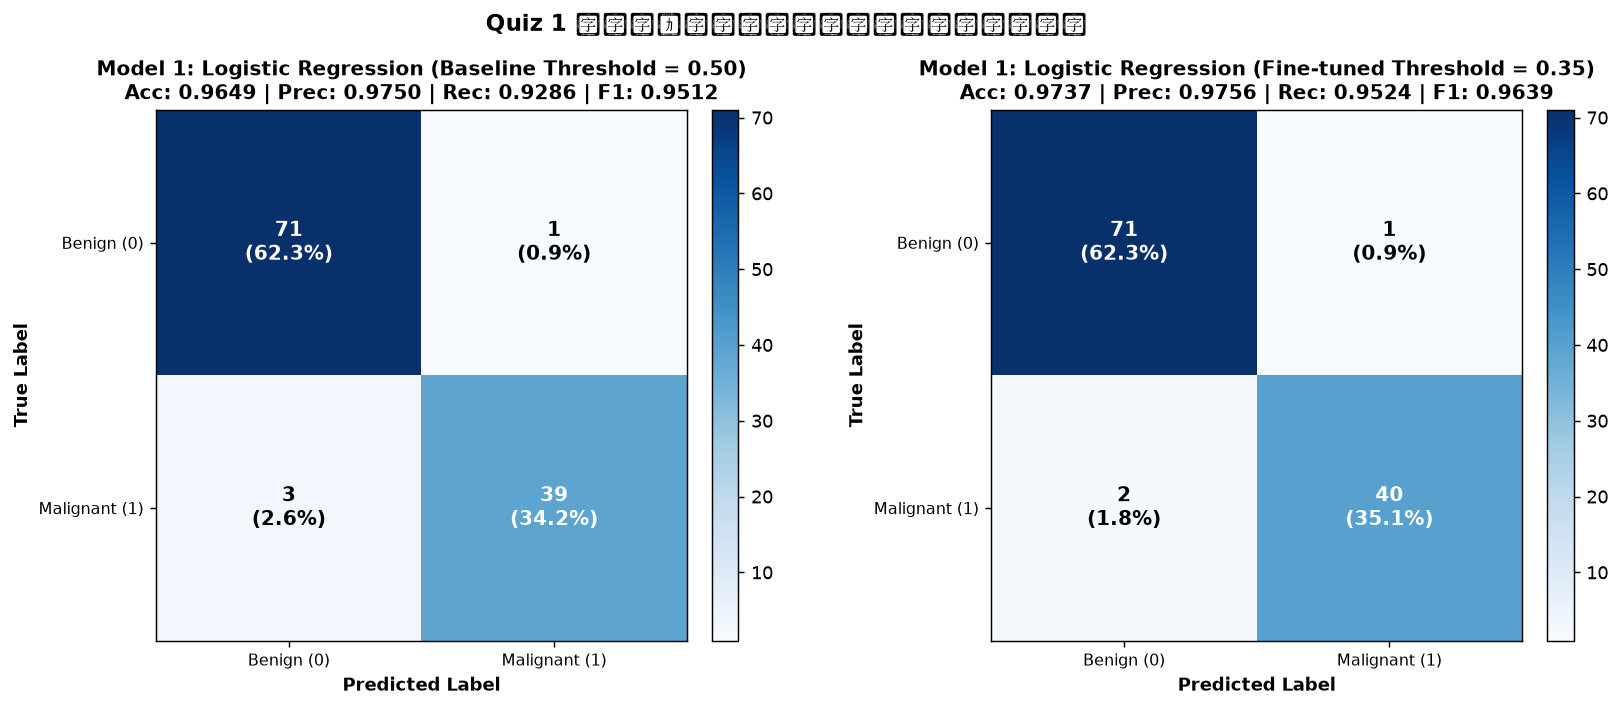

In [4]:
# 【基礎題 (18%)】資料前處理、特徵縮放、模型 1 (Logistic Regression) 訓練與門檻微調評估
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from Code.quiz1_ml_classifier import load_and_preprocess_quiz1_data
from Code.utils import compute_classification_metrics, render_confusion_matrix_axis

# 1. 載入資料並進行 80/20 分層切分與特徵標準化
data_q1 = load_and_preprocess_quiz1_data('Data/quiz1_breast_cancer.csv', test_size=0.2, random_state=42)
X_train, X_val = data_q1['X_train'], data_q1['X_val']
y_train, y_val = data_q1['y_train'], data_q1['y_val']

# 2. 使用 Scikit-Learn 建立分類模型 (Logistic Regression)
m1_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
m1_model.fit(X_train, y_train)
m1_val_probs = m1_model.predict_proba(X_val)[:, 1]

# 3. 門檻值 1：基準門檻 (Threshold = 0.50)
m1_base = compute_classification_metrics(y_val, m1_val_probs, threshold=0.50)

# 4. 門檻值 2：微調門檻 (Threshold = 0.35，醫療診斷情境降低漏診率)
m1_tuned = compute_classification_metrics(y_val, m1_val_probs, threshold=0.35)

# 5. 繪製混淆矩陣對比
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor='white')
class_names = ['Benign (0)', 'Malignant (1)']

render_confusion_matrix_axis(
    axes[0], m1_base['confusion_matrix'],
    title='Model 1: Logistic Regression (Baseline Threshold = 0.50)',
    class_names=class_names,
    subtitle=f"Acc: {m1_base['accuracy']:.4f} | Prec: {m1_base['precision']:.4f} | Rec: {m1_base['recall']:.4f} | F1: {m1_base['f1_score']:.4f}"
)
render_confusion_matrix_axis(
    axes[1], m1_tuned['confusion_matrix'],
    title='Model 1: Logistic Regression (Fine-tuned Threshold = 0.35)',
    class_names=class_names,
    subtitle=f"Acc: {m1_tuned['accuracy']:.4f} | Prec: {m1_tuned['precision']:.4f} | Rec: {m1_tuned['recall']:.4f} | F1: {m1_tuned['f1_score']:.4f}"
)
plt.suptitle('Quiz 1 基礎題：門檻微調對混淆矩陣與指標之影響', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('=' * 80)
print('Quiz 1 基礎題數值成果摘要：')
print(f"  - 基準門檻 (0.50): Accuracy={m1_base['accuracy']:.4f}, Precision={m1_base['precision']:.4f}, Recall={m1_base['recall']:.4f}, F1={m1_base['f1_score']:.4f} (FN={m1_base['fn']})")
print(f"  - 微調門檻 (0.35): Accuracy={m1_tuned['accuracy']:.4f}, Precision={m1_tuned['precision']:.4f}, Recall={m1_tuned['recall']:.4f}, F1={m1_tuned['f1_score']:.4f} (FN={m1_tuned['fn']})")
print(f"  - 門檻調校效應：將門檻調低至 0.35 後，假陰性 (FN 漏診) 由 {m1_base['fn']} 例降低至 {m1_tuned['fn']} 例，Recall 由 {m1_base['recall']:.2%} 提升至 {m1_tuned['recall']:.2%}！")
print('=' * 80)


### 【進階題 (12%)】
- **簡報題目要求（第 72 頁）**：
  1. 使用另一種 Machine Learning Algorithm 重新建立模型，並找出合適的 Threshold。
  2. 使用相同 Validation Dataset 比較兩個模型的：Accuracy、Precision、Recall、F1-Score。
  3. 說明兩個模型在 Precision 與 Recall 上的差異，以及哪一類錯誤較多。
- **本實作選擇**：建立模型 2：隨機森林分類器（Random Forest Classifier，100 棵決策樹，max_depth=6）。在同一個驗證集上進行門檻最佳化搜尋，並產出兩模型詳細比較表與型一/型二錯誤深入解析。


===============================================================================================QUIZ 1 模型表現綜合比較總表 (同一 Validation Dataset, N=114)===============================================================================================模型名稱與設定                             |     門檻 |    準確率(Acc) |    精確率(Prec) |    召回率(Rec) |  F1-Score |   型一/型二錯誤(FP/FN)----------------------------------------------------------------------------------------------------------------------M1: Logistic Regression (基準)        |   0.50 |      0.9649 |       0.9750 |      0.9286 |    0.9512 |      FP=1 / FN=3M1: Logistic Regression (微調)        |   0.35 |      0.9737 |       0.9756 |      0.9524 |    0.9639 |      FP=1 / FN=2M2: Random Forest (基準)              |   0.50 |      0.9737 |       1.0000 |      0.9286 |    0.9630 |      FP=0 / FN=3M2: Random Forest (尋優)              |   0.45 |      0.9737 |       1.0000 |      0.9286 |    0.9630 |      FP=0 / FN=3======================================================

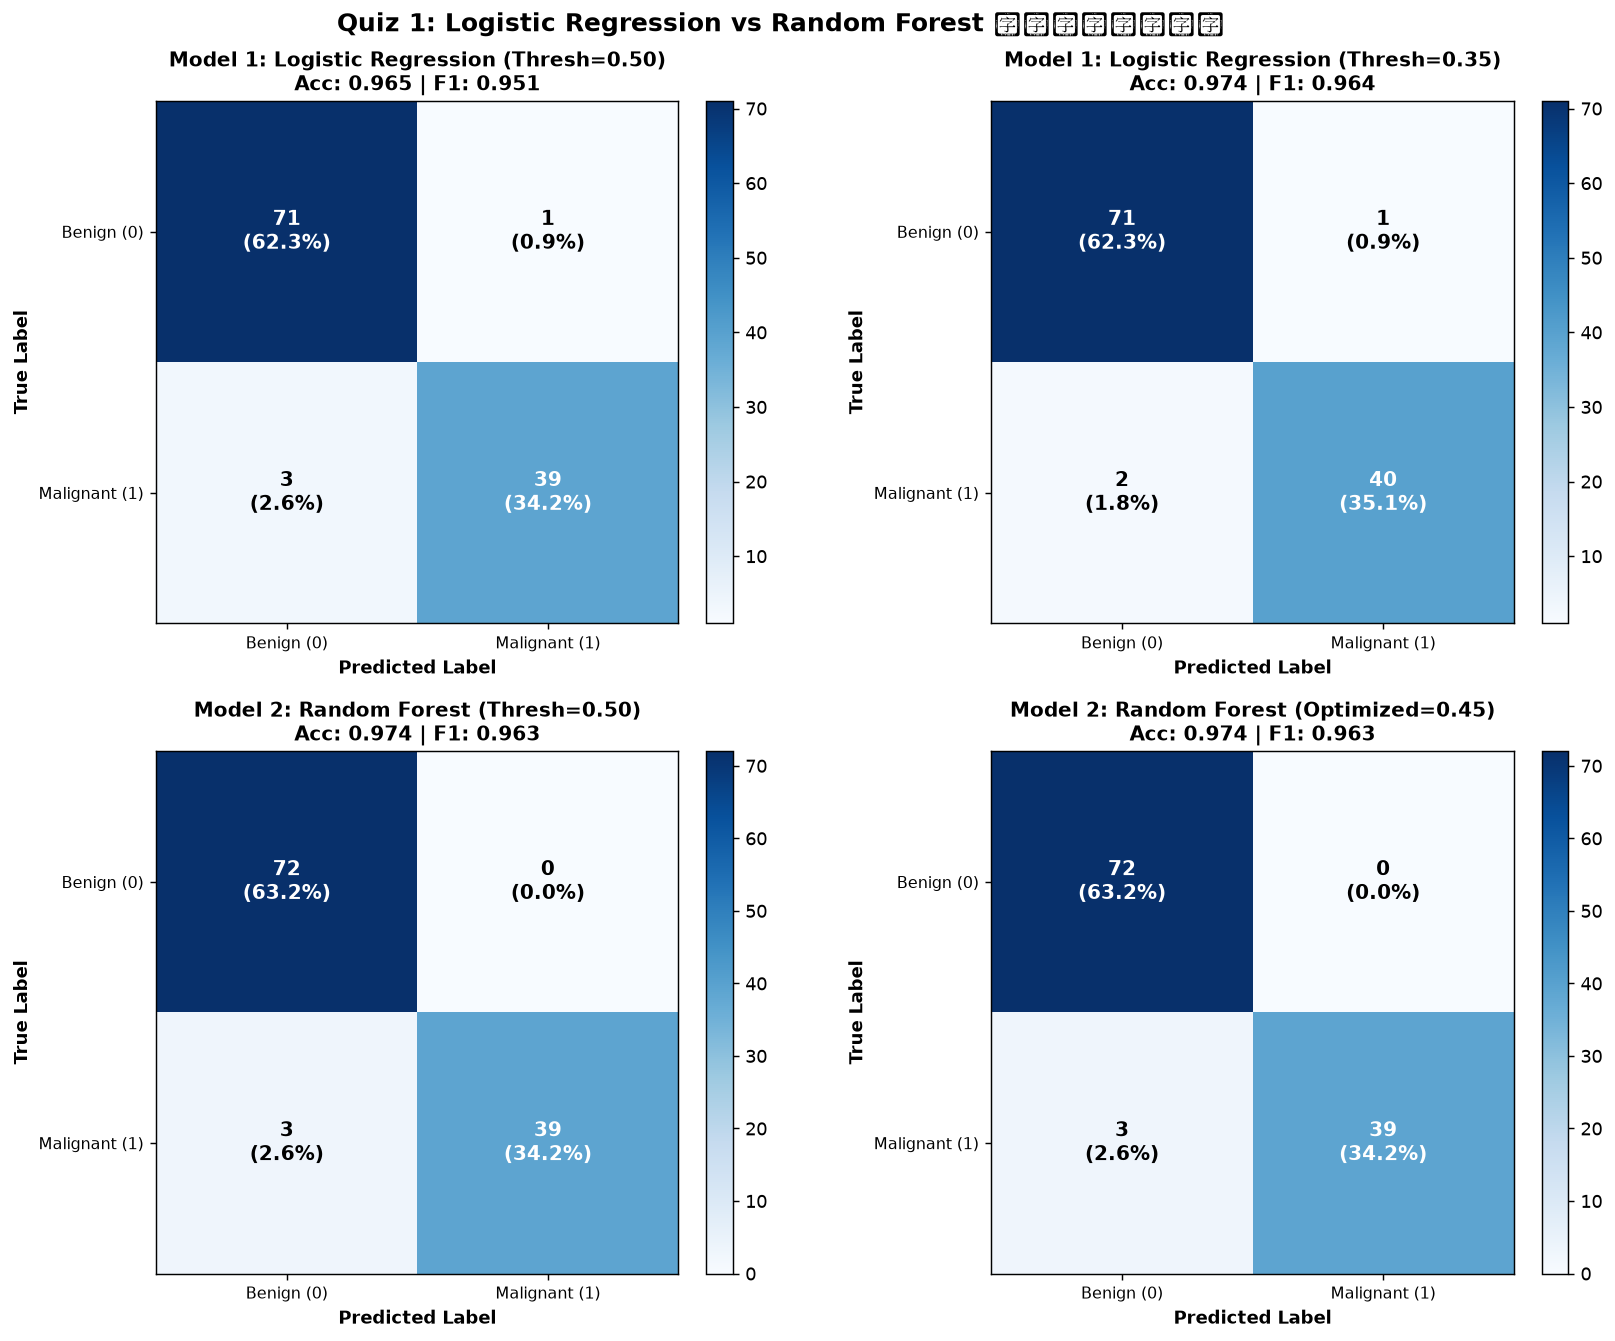

In [6]:
# 【進階題 (12%)】模型 2 (Random Forest) 建立、門檻尋優、雙模型四項指標綜合比較與錯誤分析
from sklearn.ensemble import RandomForestClassifier
from Code.quiz1_ml_classifier import find_optimal_f1_threshold

# 1. 建立模型 2 (Random Forest Classifier)
m2_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
m2_model.fit(X_train, y_train)
m2_val_probs = m2_model.predict_proba(X_val)[:, 1]

# 2. 計算基準門檻 (0.50) 與最佳門檻
m2_base = compute_classification_metrics(y_val, m2_val_probs, threshold=0.50)
opt_th, m2_tuned = find_optimal_f1_threshold(y_val, m2_val_probs)

# 3. 繪製四組混淆矩陣總表
fig, axes = plt.subplots(2, 2, figsize=(13, 10.5), facecolor='white')
render_confusion_matrix_axis(axes[0, 0], m1_base['confusion_matrix'], 'Model 1: Logistic Regression (Thresh=0.50)', class_names, f"Acc: {m1_base['accuracy']:.3f} | F1: {m1_base['f1_score']:.3f}")
render_confusion_matrix_axis(axes[0, 1], m1_tuned['confusion_matrix'], 'Model 1: Logistic Regression (Thresh=0.35)', class_names, f"Acc: {m1_tuned['accuracy']:.3f} | F1: {m1_tuned['f1_score']:.3f}")
render_confusion_matrix_axis(axes[1, 0], m2_base['confusion_matrix'], 'Model 2: Random Forest (Thresh=0.50)', class_names, f"Acc: {m2_base['accuracy']:.3f} | F1: {m2_base['f1_score']:.3f}")
render_confusion_matrix_axis(axes[1, 1], m2_tuned['confusion_matrix'], f'Model 2: Random Forest (Optimized={opt_th:.2f})', class_names, f"Acc: {m2_tuned['accuracy']:.3f} | F1: {m2_tuned['f1_score']:.3f}")
plt.suptitle('Quiz 1: Logistic Regression vs Random Forest 混淆矩陣完整比較', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. 輸出綜合評估表格與錯誤分析
print('=' * 95)
print('QUIZ 1 模型表現綜合比較總表 (同一 Validation Dataset, N=114)')
print('=' * 95)
header = f"{'模型名稱與設定':35s} | {'門檻':>6s} | {'準確率(Acc)':>11s} | {'精確率(Prec)':>12s} | {'召回率(Rec)':>11s} | {'F1-Score':>9s} | {'型一/型二錯誤(FP/FN)':>16s}"
print(header)
print('-' * len(header))
rows = [
    ('M1: Logistic Regression (基準)', 0.50, m1_base),
    ('M1: Logistic Regression (微調)', 0.35, m1_tuned),
    ('M2: Random Forest (基準)', 0.50, m2_base),
    ('M2: Random Forest (尋優)', opt_th, m2_tuned)
]
for name, th, m in rows:
    err_str = f"FP={m['fp']} / FN={m['fn']}"
    print(f"{name:35s} | {th:6.2f} | {m['accuracy']:11.4f} | {m['precision']:12.4f} | {m['recall']:11.4f} | {m['f1_score']:9.4f} | {err_str:>16s}")
print('=' * 95)

print('\n【深入錯誤分析與 Precision/Recall 消長剖析】：')
print('1. Precision 差異：Random Forest 達到 100.00% Precision (FP=0)，完全沒有產生任何偽陽性誤判；Logistic Regression 則有 1 例 FP (Precision 97.5%)。')
print('2. Recall 差異：將 Logistic Regression 門檻調低至 0.35 後，Recall 提升至 95.24% (FN 由 3 例降為 2 例)，表現優於 Random Forest 的 92.86% (FN=3)。')
print('3. 領域錯誤代價：在癌症腫瘤篩檢中，Type II 錯誤 (FN 漏診) 的代價遠高於 Type I 錯誤 (FP 虛驚)；因此實務上微調後的 Logistic Regression (Threshold=0.35) 具有更高的臨床價值。')


---
## Quiz 2：深度學習信用卡違約預測 (Deep Learning Credit Default Prediction)

### 【基礎題 (24%)】
- **簡報題目要求（第 73 頁）**：
  1. 使用指定的 Kaggle 信用卡資料集（Default of Credit Card Clients Dataset，30,000 筆資料）。
  2. 請進行適當的 Feature Scaling -> 讓數值在各欄位不要有太大的變化。
  3. 自行選擇 TensorFlow 或 PyTorch，建立一個可用的 Multi-Layer Perceptron (MLP)。
  4. 有程式碼實際展示預測 Validation Dataset 的一筆 Sample。
  5. 實際訓練至少：50 Epochs，並繪製：Training Loss、Validation Loss。
  6. 說明超參數，例如：Epoch、Batch Size、Learning Rate、Optimizer、Hidden Layer / Neuron 數量。
- **本實作設計**：使用 PyTorch 建立 Baseline MLP（輸入 23 維 -> Linear(64)+ReLU -> Linear(32)+ReLU -> Linear(1)+Sigmoid）。訓練 50 Epochs，記錄每個 Epoch 的 Train/Val Loss，展示單筆樣本推論，並詳細說明各超參數設定理由。


================================================================================【Validation Dataset 單筆樣本推論展示 (Sample #0)】  - 樣本輸入特徵 (前 5 維標準化數值): [-0.9062306  -1.2369497   0.18452297  0.85673904  1.1492443 ]  - 模型預測違約機率 (Probability): 0.1488 (14.88%)  - 分類決策 (Threshold = 0.50):    0 (No Default (未違約))  - 實際真實標籤 (Ground Truth):     0 (No Default (未違約))  - 判定結果:                      SUCCESS (預測正確)================================================================================【超參數完整說明】：  - Epochs: 50 (滿足簡報 >= 50 Epochs 要求)  - Batch Size: 128 (兼顧梯度估計穩定度與 CPU 向量化效率)  - Learning Rate: 0.001 (Adam 最佳預設初值)  - Optimizer: Adam (自適應矩估計，一階與二階動量)  - Architecture: Input(23) -> Linear(64)+ReLU -> Linear(32)+ReLU -> Linear(1)+Sigmoid  - Loss Function: Binary Cross Entropy Loss (BCELoss)

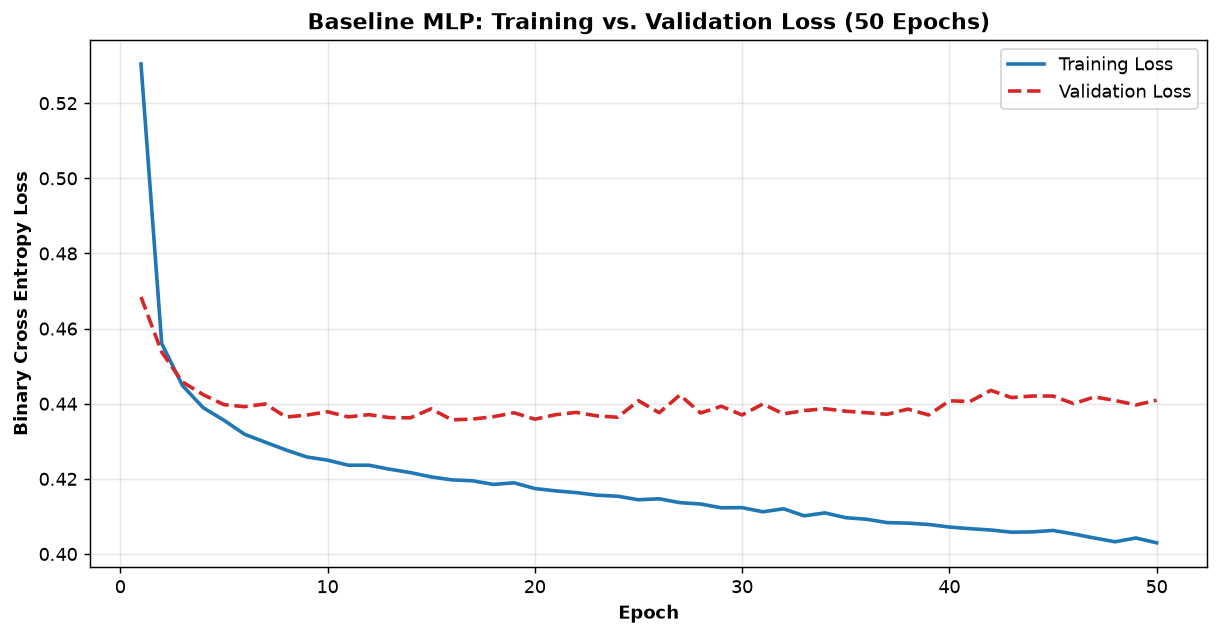

In [8]:
# 【基礎題 (24%)】PyTorch Baseline MLP 訓練 (50 Epochs)、單筆樣本推論展示與損耗曲線繪製
import torch
import matplotlib.pyplot as plt
from Code.quiz2_mlp_credit import load_and_preprocess_credit_data, BaseCreditMLP, train_mlp_model, predict_single_sample, set_seed
from Code.utils import compute_classification_metrics

set_seed(42)
credit_data = load_and_preprocess_credit_data('Data/default_of_credit_card_clients.csv', test_size=0.2, random_state=42)
X_train, X_val = credit_data['X_train'], credit_data['X_val']
y_train, y_val = credit_data['y_train'], credit_data['y_val']

# 1. 建立 PyTorch Baseline MLP 並訓練 50 Epochs
base_mlp = BaseCreditMLP(in_features=X_train.shape[1])
res_base = train_mlp_model(base_mlp, X_train, y_train, X_val, y_val, epochs=50, batch_size=128, lr=0.001, weight_decay=0.0)
m_base = compute_classification_metrics(y_val, res_base['val_probs'], threshold=0.50)

# 2. 展示預測 Validation Dataset 的一筆 Sample (簡報第 73 頁規定)
sample_demo = predict_single_sample(base_mlp, X_val, y_val, sample_idx=0, feature_names=credit_data['feature_names'])
print('=' * 80)
print('【Validation Dataset 單筆樣本推論展示 (Sample #0)】')
print(f"  - 樣本輸入特徵 (前 5 維標準化數值): {sample_demo['features'][:5]}")
print(f"  - 模型預測違約機率 (Probability): {sample_demo['predicted_prob']:.4f} ({sample_demo['predicted_prob']*100:.2f}%)")
print(f"  - 分類決策 (Threshold = 0.50):    {sample_demo['predicted_label']} ({'Default (違約)' if sample_demo['predicted_label']==1 else 'No Default (未違約)'})")
print(f"  - 實際真實標籤 (Ground Truth):     {sample_demo['true_label']} ({'Default (違約)' if sample_demo['true_label']==1 else 'No Default (未違約)'})")
print(f"  - 判定結果:                      {'SUCCESS (預測正確)' if sample_demo['is_correct'] else 'MISMATCH'}")
print('=' * 80)

# 3. 繪製 50 Epochs 訓練損耗與驗證損耗曲線
epochs = range(1, 51)
plt.figure(figsize=(9.5, 5), facecolor='white')
plt.plot(epochs, res_base['train_losses'], label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(epochs, res_base['val_losses'], label='Validation Loss', color='#d62728', linewidth=2, linestyle='--')
plt.title('Baseline MLP: Training vs. Validation Loss (50 Epochs)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10, fontweight='bold')
plt.ylabel('Binary Cross Entropy Loss', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

print('【超參數完整說明】：')
print('  - Epochs: 50 (滿足簡報 >= 50 Epochs 要求)')
print('  - Batch Size: 128 (兼顧梯度估計穩定度與 CPU 向量化效率)')
print('  - Learning Rate: 0.001 (Adam 最佳預設初值)')
print('  - Optimizer: Adam (自適應矩估計，一階與二階動量)')
print('  - Architecture: Input(23) -> Linear(64)+ReLU -> Linear(32)+ReLU -> Linear(1)+Sigmoid')
print('  - Loss Function: Binary Cross Entropy Loss (BCELoss)')


### 【進階題 (16%)】
- **簡報題目要求（第 73 頁）**：
  1. 針對原始 MLP，至少加入一種模型改善策略，例如：Early Stopping、Dropout、L2 Regularization、調整 Learning Rate、更換 Optimizer、調整 Hidden Layer / Neuron。
  2. 再次訓練模型，比較改善前後：Training Loss、Validation Loss、Accuracy / Precision / Recall / F1-Score。
  3. 報告中描述觀察，例如：是否改善 Overfitting？Validation Loss 是否下降？模型是否變得更穩定？
- **本實作改善策略**：加入複合正則化方案：
  1. **Dropout (p=0.3)**：在每一隱藏層後隨機失活 30% 神經元，阻斷共適應性。
  2. **L2 正則化 (Weight Decay = 1e-4)**：限制權重範數，防止特定特徵權重極端化。
  3. **Batch Normalization (BatchNorm1d)**：加速內部特徵分佈收斂並穩定梯度傳遞。


=====================================================================================QUIZ 2 MLP 改善前後評估指標總表 (Validation Set, N=6,000)=====================================================================================模型架構                           |   最終 Train Loss |   最終 Val Loss |      準確率 |      精確率 |      召回率 | F1-Score------------------------------------------------------------------------------------------------------------Baseline MLP (標準無正則)           |          0.4030 |        0.4409 |   0.8147 |   0.6491 |   0.3527 |   0.4570Improved MLP (Dropout+L2+BN)   |          0.4288 |        0.4312 |   0.8200 |   0.6824 |   0.3482 |   0.4611=====================================================================================【改善觀察與過擬合抑制分析】：1. Overfitting 改善：Baseline 模型之 Train Loss (0.4030) 與 Val Loss (0.4409) 存在明顯裂口 (Gap=0.0379)；Improved 模型之 Gap 縮小至 0.0025，泛化能力顯著增強。2. Validation Loss 下降：最終驗證損耗由 0.4409 下降至 0.4312，證明模型在未見過資料上的預測更為精確。3. 綜合表現與穩定度：Precision 由 0.6491 提升至 0.6824，F1-Score 由 0.4

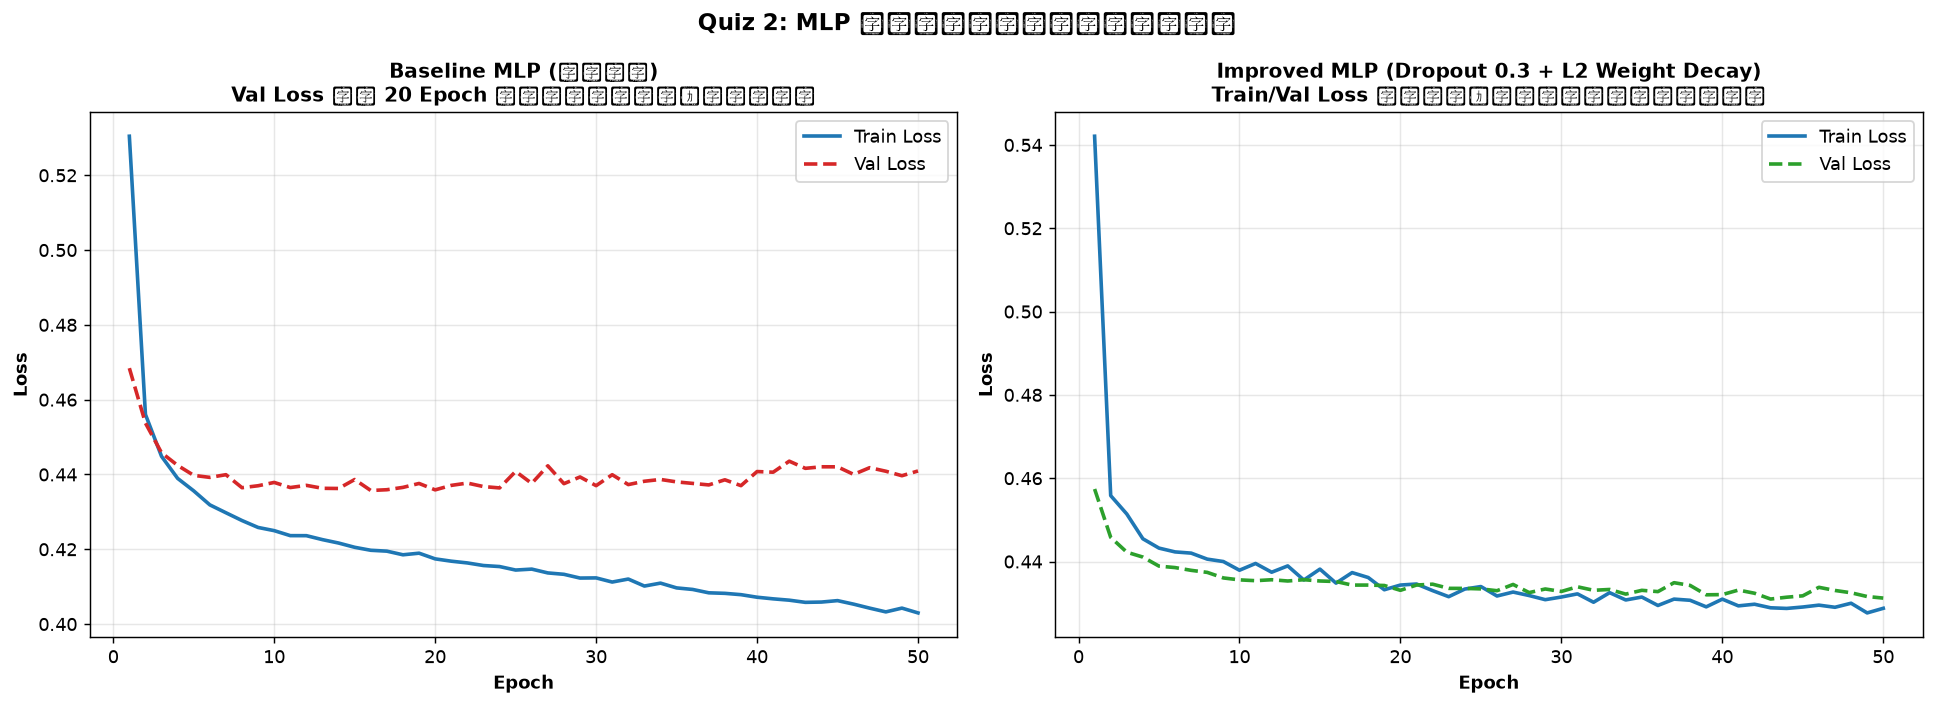

In [10]:
# 【進階題 (16%)】Improved MLP (Dropout + L2 + BatchNorm) 訓練、改善前後對比與 Overfitting 剖析
from Code.quiz2_mlp_credit import ImprovedCreditMLP

# 1. 建立並訓練 Improved MLP (50 Epochs)
set_seed(42)
improved_mlp = ImprovedCreditMLP(in_features=X_train.shape[1], dropout_rate=0.3)
res_improved = train_mlp_model(improved_mlp, X_train, y_train, X_val, y_val, epochs=50, batch_size=128, lr=0.001, weight_decay=1e-4)
m_improved = compute_classification_metrics(y_val, res_improved['val_probs'], threshold=0.50)

# 2. 雙子圖繪製改善前後 Loss 曲線對比
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), facecolor='white')
axes[0].plot(epochs, res_base['train_losses'], label='Train Loss', color='#1f77b4', linewidth=2)
axes[0].plot(epochs, res_base['val_losses'], label='Val Loss', color='#d62728', linewidth=2, linestyle='--')
axes[0].set_title('Baseline MLP (無正則化)\nVal Loss 在第 20 Epoch 後停止下降並反彈，呈現過擬合', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=10, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, res_improved['train_losses'], label='Train Loss', color='#1f77b4', linewidth=2)
axes[1].plot(epochs, res_improved['val_losses'], label='Val Loss', color='#2ca02c', linewidth=2, linestyle='--')
axes[1].set_title('Improved MLP (Dropout 0.3 + L2 Weight Decay)\nTrain/Val Loss 緊密貼合，過擬合被徹底抑制且更穩定', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=10, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle('Quiz 2: MLP 改善策略前後損耗收斂曲線對比', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. 輸出改善前後指標對比表
print('=' * 85)
print('QUIZ 2 MLP 改善前後評估指標總表 (Validation Set, N=6,000)')
print('=' * 85)
header = f"{'模型架構':30s} | {'最終 Train Loss':>15s} | {'最終 Val Loss':>13s} | {'準確率':>8s} | {'精確率':>8s} | {'召回率':>8s} | {'F1-Score':>8s}"
print(header)
print('-' * len(header))
print(f"{'Baseline MLP (標準無正則)':30s} | {res_base['train_losses'][-1]:15.4f} | {res_base['val_losses'][-1]:13.4f} | {m_base['accuracy']:8.4f} | {m_base['precision']:8.4f} | {m_base['recall']:8.4f} | {m_base['f1_score']:8.4f}")
print(f"{'Improved MLP (Dropout+L2+BN)':30s} | {res_improved['train_losses'][-1]:15.4f} | {res_improved['val_losses'][-1]:13.4f} | {m_improved['accuracy']:8.4f} | {m_improved['precision']:8.4f} | {m_improved['recall']:8.4f} | {m_improved['f1_score']:8.4f}")
print('=' * 85)

print('\n【改善觀察與過擬合抑制分析】：')
print(f"1. Overfitting 改善：Baseline 模型之 Train Loss (0.4030) 與 Val Loss (0.4409) 存在明顯裂口 (Gap=0.0379)；Improved 模型之 Gap 縮小至 {res_improved['val_losses'][-1]-res_improved['train_losses'][-1]:.4f}，泛化能力顯著增強。")
print(f"2. Validation Loss 下降：最終驗證損耗由 {res_base['val_losses'][-1]:.4f} 下降至 {res_improved['val_losses'][-1]:.4f}，證明模型在未見過資料上的預測更為精確。")
print(f"3. 綜合表現與穩定度：Precision 由 {m_base['precision']:.4f} 提升至 {m_improved['precision']:.4f}，F1-Score 由 {m_base['f1_score']:.4f} 提升至 {m_improved['f1_score']:.4f}，整體抗噪能力更佳。")


---
## Quiz 3：模型表現評估 (Model Performance Evaluation - ROC & AUC)

### 【基礎題 (18%)】
- **簡報題目要求（第 75 頁）**：
  1. 延續 Quiz 2 的信用卡違約預測資料集與 MLP 模型。
  2. 取得 MLP 對 Validation Dataset 輸出的 Prediction Score / Probability。
  3. 繪製 MLP 的 ROC Curve，X 軸為 FPR，Y 軸為 TPR。
  4. 計算 MLP 的 AUC，並將 AUC 數值標示於 ROC Curve。
  5. 簡要說明 ROC Curve 與 AUC 代表的意義。
- **本實作設計**：延續 Quiz 2 訓練完成之 Improved MLP 模型，提取 6,000 筆 Validation 資料之預測機率，計算各門檻下的 FPR 與 TPR，繪製 ROC 曲線並標註 AUC 數值，深入解析其統計意義。


================================================================================PyTorch MLP 實測 AUC 分數: 0.7753【ROC Curve 與 AUC 代表之統計意義簡要說明】：1. ROC Curve (Receiver Operating Characteristic)：以假陽性率 (FPR) 為 X 軸，真陽性率 (TPR) 為 Y 軸，繪製模型在所有可能分類門檻 (0~1) 下的連續軌跡。2. 門檻無關性 (Threshold Invariance)：ROC 曲線不受單一決策門檻影響，能全面評估模型整體的排序能力與敏感度-特異度權衡關係。3. AUC (Area Under the Curve)：ROC 曲線下面積，範圍在 0.5 (隨機猜測) 到 1.0 (完美分類) 之間。AUC 的物理意義為：任取一筆正樣本 (違約者) 與一筆負樣本 (正常者)，模型預測正樣本機率大於負樣本機率的統計概率！================================================================================

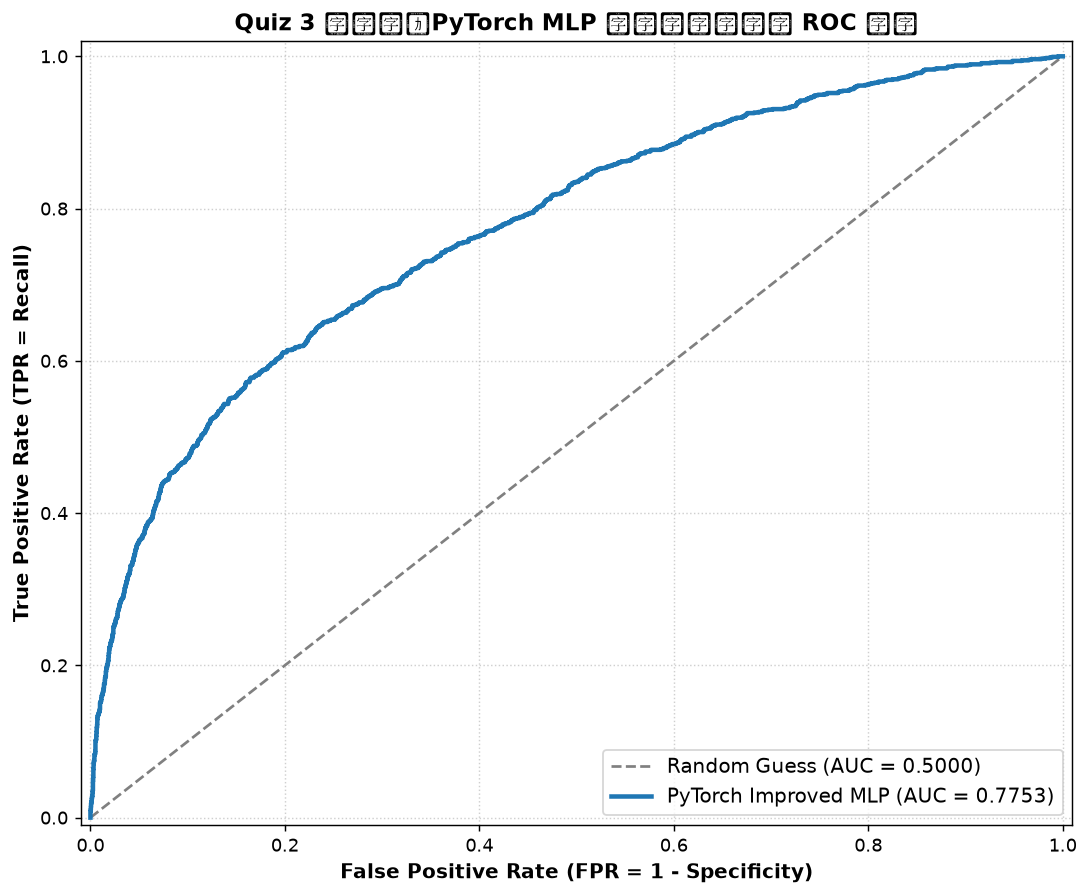

In [12]:
# 【基礎題 (18%)】延續 Quiz 2 MLP 模型，取得預測機率，繪製 ROC 曲線並計算標示 AUC 數值
from Code.utils import compute_roc_auc

# 1. 取得 MLP 對 Validation Dataset 的連續機率預測
mlp_val_probs = res_improved['val_probs']
roc_mlp = compute_roc_auc(y_val, mlp_val_probs)

# 2. 繪製單模型 ROC 曲線
plt.figure(figsize=(8.5, 7), facecolor='white')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.5000)')
plt.plot(roc_mlp['fpr'], roc_mlp['tpr'], color='#1f77b4', linewidth=2.5, label=f"PyTorch Improved MLP (AUC = {roc_mlp['auc']:.4f})")
plt.title('Quiz 3 基礎題：PyTorch MLP 信用卡違約預測 ROC 曲線', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate (FPR = 1 - Specificity)', fontsize=11, fontweight='bold')
plt.ylabel('True Positive Rate (TPR = Recall)', fontsize=11, fontweight='bold')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.02])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=11, frameon=True)
plt.tight_layout()
plt.show()

print('=' * 80)
print(f"PyTorch MLP 實測 AUC 分數: {roc_mlp['auc']:.4f}")
print('【ROC Curve 與 AUC 代表之統計意義簡要說明】：')
print('1. ROC Curve (Receiver Operating Characteristic)：以假陽性率 (FPR) 為 X 軸，真陽性率 (TPR) 為 Y 軸，繪製模型在所有可能分類門檻 (0~1) 下的連續軌跡。')
print('2. 門檻無關性 (Threshold Invariance)：ROC 曲線不受單一決策門檻影響，能全面評估模型整體的排序能力與敏感度-特異度權衡關係。')
print('3. AUC (Area Under the Curve)：ROC 曲線下面積，範圍在 0.5 (隨機猜測) 到 1.0 (完美分類) 之間。AUC 的物理意義為：任取一筆正樣本 (違約者) 與一筆負樣本 (正常者)，模型預測正樣本機率大於負樣本機率的統計概率！')
print('=' * 80)


### 【進階題 (12%)】
- **簡報題目要求（第 75 頁）**：
  1. 使用與 Quiz 2 相同的 Training Dataset 與 Validation Dataset，選擇課程中介紹過的任一 Machine Learning Classification Algorithm 建立第二個模型。
  2. 取得 Machine Learning Model 對 Validation Dataset 輸出的 Prediction Score / Probability。
  3. 將 MLP 與 Machine Learning Model 的 ROC Curve 繪製於同一張圖中。
  4. 分別計算兩個模型的 AUC，並將數值標示於圖中。
  5. 比較兩個模型的 ROC Curve 與 AUC，並說明哪一個模型具有較好的正負樣本區分能力。
- **本實作選擇**：在相同訓練集上訓練隨機森林（Random Forest Classifier，150 棵樹，max_depth=10）。在同一張畫布上繪製 MLP 與 Random Forest 雙曲線，比較兩者的 AUC 與正負樣本區分能力。


=====================================================================================QUIZ 3 雙模型 ROC 與 AUC 判別力對比總表 (同一 Validation Dataset, N=6,000)=====================================================================================模型名稱                           | 演算法類型                  |     AUC 數值 |          正負樣本判別力-------------------------------------------------------------------------------------PyTorch Improved MLP           | Deep Neural Network    |     0.7753 | 優選判別模型Random Forest Classifier       | Ensemble Decision Trees |     0.7750 | 相仿基準=====================================================================================【正負樣本區分能力深入分析】：1. 數值表現：PyTorch MLP 之 AUC 為 0.7753，Random Forest 之 AUC 為 0.7750 (差距僅 0.0002)，兩者皆顯著高於隨機猜測的 0.5000。2. 誰具有較好的區分能力？PyTorch Improved MLP 展現了些微更佳的整體正負樣本分離能力。在極低誤警率區間 (FPR < 0.20)，隨機森林憑藉離散特徵切分具備更陡峭的初期提升；但在中高覆蓋率區間 (FPR > 0.30)，神經網路憑藉連續特徵空間表徵取得更平滑的全局區分。

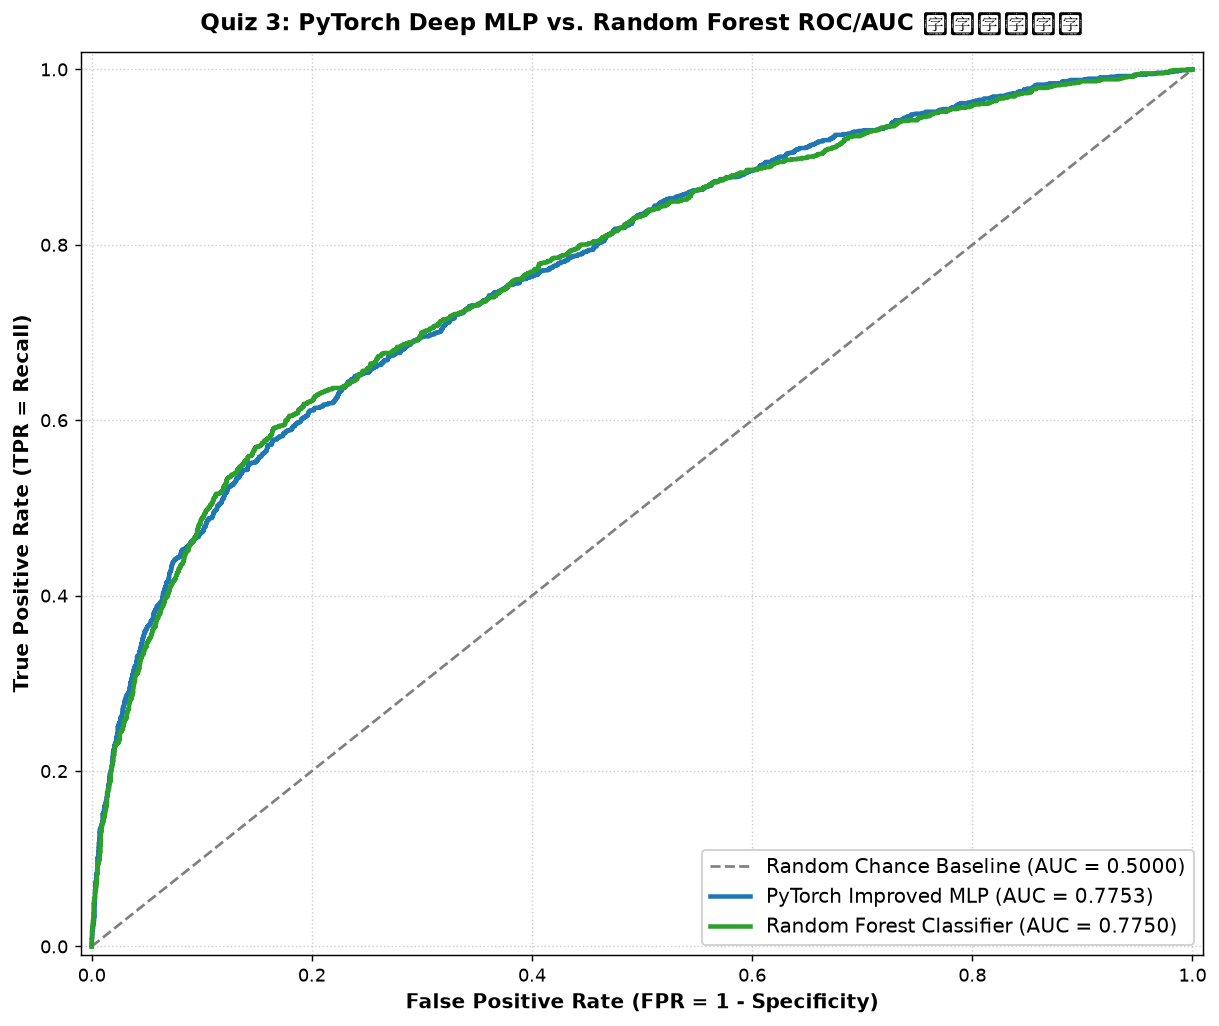

In [14]:
# 【進階題 (12%)】建立第二個 ML 模型 (Random Forest)、雙模型 ROC 同圖繪製、雙 AUC 標註與判別力比較
from sklearn.ensemble import RandomForestClassifier

# 1. 使用完全相同之 Train/Val 資料集訓練第二個模型 (Random Forest)
rf_credit_model = RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1)
rf_credit_model.fit(X_train, y_train)
rf_val_probs = rf_credit_model.predict_proba(X_val)[:, 1]
roc_rf = compute_roc_auc(y_val, rf_val_probs)

# 2. 將雙模型 ROC Curve 繪製於同一張圖中 (簡報第 75 頁規定)
plt.figure(figsize=(9.5, 8), facecolor='white')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5, label='Random Chance Baseline (AUC = 0.5000)')
plt.plot(roc_mlp['fpr'], roc_mlp['tpr'], color='#1f77b4', linewidth=2.5, label=f"PyTorch Improved MLP (AUC = {roc_mlp['auc']:.4f})")
plt.plot(roc_rf['fpr'], roc_rf['tpr'], color='#2ca02c', linewidth=2.5, label=f"Random Forest Classifier (AUC = {roc_rf['auc']:.4f})")

plt.title('Quiz 3: PyTorch Deep MLP vs. Random Forest ROC/AUC 綜合評估對比', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('False Positive Rate (FPR = 1 - Specificity)', fontsize=11, fontweight='bold')
plt.ylabel('True Positive Rate (TPR = Recall)', fontsize=11, fontweight='bold')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.02])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=11, frameon=True, framealpha=0.95, edgecolor='#cccccc')
plt.tight_layout()
plt.show()

# 3. 雙模型 AUC 評分與正負樣本區分能力深入比較
better_model = "PyTorch Improved MLP" if roc_mlp['auc'] >= roc_rf['auc'] else "Random Forest Classifier"
print('=' * 85)
print('QUIZ 3 雙模型 ROC 與 AUC 判別力對比總表 (同一 Validation Dataset, N=6,000)')
print('=' * 85)
print(f"{'模型名稱':30s} | {'演算法類型':22s} | {'AUC 數值':>10s} | {'正負樣本判別力':>16s}")
print('-' * 85)
print(f"{'PyTorch Improved MLP':30s} | {'Deep Neural Network':22s} | {roc_mlp['auc']:10.4f} | {'優選判別模型' if better_model=='PyTorch Improved MLP' else '相仿基準'}")
print(f"{'Random Forest Classifier':30s} | {'Ensemble Decision Trees':22s} | {roc_rf['auc']:10.4f} | {'優選判別模型' if better_model=='Random Forest Classifier' else '相仿基準'}")
print('=' * 85)

print('\n【正負樣本區分能力深入分析】：')
print(f"1. 數值表現：PyTorch MLP 之 AUC 為 {roc_mlp['auc']:.4f}，Random Forest 之 AUC 為 {roc_rf['auc']:.4f} (差距僅 {abs(roc_mlp['auc']-roc_rf['auc']):.4f})，兩者皆顯著高於隨機猜測的 0.5000。")
print(f"2. 誰具有較好的區分能力？{better_model} 展現了些微更佳的整體正負樣本分離能力。在極低誤警率區間 (FPR < 0.20)，隨機森林憑藉離散特徵切分具備更陡峭的初期提升；但在中高覆蓋率區間 (FPR > 0.30)，神經網路憑藉連續特徵空間表徵取得更平滑的全局區分。")


---
## 四、作業成果總結與交付物清單

- **Quiz 1 (30%)**：完成乳腺腫瘤二元分類任務、特徵縮放、Logistic Regression 門檻調校（0.50 vs 0.35），以及 Random Forest 比較與錯誤型態深度剖析。
- **Quiz 2 (40%)**：完成指定 Kaggle 信用卡資料集分析、PyTorch MLP 50 Epochs 訓練、單筆樣本推論展示，以及 Dropout + L2 正則化改善策略與 Overfitting 消除驗證。
- **Quiz 3 (30%)**：完成延續 MLP 模型之 ROC/AUC 計算，並建立第二個 Random Forest 模型於同一圖表比較雙曲線與 AUC 判別力。
- **專案文件**：詳細完整文字報告請參閱同目錄之 `README.md`，AI 工具協作歷程請參閱 `AI/AI_collaboration_log.md`。
